<a href="https://colab.research.google.com/github/Aniruddha-png/ECSR/blob/main/Text_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install transformers datasets accelerate torchmetrics scikit-learn matplotlib seaborn
!pip -q install clean-text emoji ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files
import zipfile, os

# Upload the zip file
uploaded = files.upload()   # choose your zip file

# Extract it
for fname in uploaded.keys():
    zip_path = fname
    extract_dir = "/content/data"
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

print("✅ Files extracted to:", extract_dir)
!ls -lh /content/data


Saving archive_text.zip to archive_text.zip
✅ Files extracted to: /content/data
total 2.0M
-rw-r--r-- 1 root root 202K Aug 24 18:09 test.txt
-rw-r--r-- 1 root root 1.6M Aug 24 18:09 train.txt
-rw-r--r-- 1 root root 200K Aug 24 18:09 val.txt


In [ ]:
import pandas as pd, numpy as np, re, emoji, ftfy
from cleantext import clean

def read_split(path):
    # Files have "text \t label"
    df = pd.read_csv(path, sep=';', names=['text','label'], header=None, engine='python')
    # Some versions use tab or semicolon; try to auto-fix if only 1 column read
    if df.shape[1] == 1:
        df = pd.read_csv(path, sep='\t', names=['text','label'], header=None, engine='python')
    return df

train_df = read_split('/content/data/train.txt')
val_df   = read_split('/content/data/val.txt')
test_df  = read_split('/content/data/test.txt')

print(train_df.head(), train_df['label'].value_counts(), sep="\n\n")
print(val_df['label'].value_counts(), test_df['label'].value_counts(), sep="\n\n")

# Normalization/cleaning
def basic_clean(s):
    if not isinstance(s, str): return ""
    s = ftfy.fix_text(s)
    s = clean(
        s,
        to_ascii=False,
        lower=True,
        no_line_breaks=True,
        no_urls=True,
        no_emails=True,
        no_phone_numbers=True,
        no_numbers=False,    # numbers can carry sentiment (e.g., "100% happy")
        no_digits=False,
        no_currency_symbols=True,
        no_punct=False       # keep punctuation for context
    )
    # Normalize whitespace
    s = re.sub(r'\s+', ' ', s).strip()
    return s

for df in (train_df, val_df, test_df):
    df['text'] = df['text'].astype(str).map(basic_clean)

# Label mapping (dataset has 6 classes)
labels = sorted(train_df['label'].unique())
label2id = {lab:i for i, lab in enumerate(labels)}
id2label = {i:lab for lab,i in label2id.items()}
num_labels = len(labels)
train_df['label_id'] = train_df['label'].map(label2id)
val_df['label_id']   = val_df['label'].map(label2id)
test_df['label_id']  = test_df['label'].map(label2id)

labels, label2id


                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
label
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

label
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64


(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
 {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5})

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

MODEL_NAME = "roberta-large"  # try "roberta-large" for extra headroom (reduce batch size)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

MAX_LEN = 96  # long enough for most sentences; adjust if your texts are longer

class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df['text'].tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = EmotionDataset(train_df, tokenizer, MAX_LEN)
val_ds   = EmotionDataset(val_df, tokenizer, MAX_LEN)
test_ds  = EmotionDataset(test_df, tokenizer, MAX_LEN)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H, mask):
        # H: (B, L, 2H)
        scores = torch.tanh(self.W(H))   # (B, L, H)
        scores = self.v(scores).squeeze(-1)   # (B, L)

        if mask is not None:
            # ✅ Use float() to avoid FP16 overflow
            scores = scores.float().masked_fill(mask == 0, -1e4)

        attn = torch.softmax(scores, dim=-1)  # (B, L)
        context = torch.bmm(attn.unsqueeze(1), H).squeeze(1)  # (B, 2H)
        return context


class EmoModel(nn.Module):
    def __init__(self, model_name, num_labels, rnn_type='gru', rnn_hidden=256, dropout=0.2):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(model_name)
        hidden_t = self.transformer.config.hidden_size  # 768 for base
        self.rnn_type = rnn_type.lower()

        rnn_cls = nn.GRU if self.rnn_type == 'gru' else nn.LSTM
        self.birnn = rnn_cls(
            input_size=hidden_t,
            hidden_size=rnn_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.attn = Attention(hidden_size=rnn_hidden*2)

        fusion_in = hidden_t + rnn_hidden*2  # CLS + Attn(BiRNN)
        self.ffn = nn.Sequential(
            nn.Linear(fusion_in, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=False, return_dict=True)
        last_hidden = outputs.last_hidden_state            # (B, L, H)
        cls_vec = last_hidden[:, 0, :]                    # CLS token for RoBERTa/BERT

        rnn_out, _ = self.birnn(last_hidden)              # (B, L, 2*rnn_hidden)
        context_vec, attn = self.attn(rnn_out, mask=attention_mask)

        fused = torch.cat([cls_vec, context_vec], dim=-1) # (B, H + 2*rnn_hidden)
        feats = self.ffn(fused)
        logits = self.classifier(feats)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return {'loss': loss, 'logits': logits, 'attn': attn}


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

# -------------------
# Attention Mechanism
# -------------------
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H, mask):
        # H: (B, L, 2H)
        scores = torch.tanh(self.W(H))           # (B, L, H)
        scores = self.v(scores).squeeze(-1)      # (B, L)

        if mask is not None:
            # ✅ Safe masking with float() to prevent FP16 overflow
            scores = scores.float().masked_fill(mask == 0, -1e4)

        attn = torch.softmax(scores, dim=-1)     # (B, L)
        context = torch.bmm(attn.unsqueeze(1), H).squeeze(1)  # (B, 2H)
        return context

# -------------------
# Emotion Classifier
# -------------------
class EmotionClassifier(nn.Module):
    def __init__(self, model_name, num_labels, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        bert_dim = self.bert.config.hidden_size

        # BiGRU (or BiLSTM)
        self.bigru = nn.GRU(
            input_size=bert_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Attention
        self.attention = Attention(hidden_dim)

        # Fusion: CLS + BiGRU+Attn
        fusion_dim = bert_dim + (2 * hidden_dim)
        self.fc1 = nn.Linear(fusion_dim, 256)
        self.dropout = nn.Dropout(dropout)
        self.out = nn.Linear(256, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        # Transformer encoder
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = outputs.last_hidden_state[:, 0]    # CLS vector
        seq_emb = outputs.last_hidden_state          # (B, L, H)

        # BiGRU
        H, _ = self.bigru(seq_emb)                   # (B, L, 2H)

        # Attention
        context = self.attention(H, attention_mask)  # (B, 2H)

        # Fusion
        fused = torch.cat([cls_emb, context], dim=1) # (B, fusion_dim)
        x = self.dropout(torch.relu(self.fc1(fused)))
        logits = self.out(x)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

        return {"loss": loss, "logits": logits}


In [ ]:
import torch
import torch.nn as nn

# --- PATCH: Attention with FP16-safe masking and dtype alignment ---

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, H, mask=None):
        scores = torch.tanh(self.W(H))            # (B, L, H)
        scores = self.v(scores).squeeze(-1)       # (B, L)

        if mask is not None:
            if mask.dtype != torch.bool:
                mask = mask.bool()
            neg = torch.tensor(-1e4, dtype=scores.dtype, device=scores.device)
            scores = scores.masked_fill(~mask, neg)

        attn = torch.softmax(scores, dim=-1)      # (B, L)
        if attn.dtype != H.dtype:
            attn = attn.to(H.dtype)

        context = torch.bmm(attn.unsqueeze(1), H).squeeze(1)  # (B, D)
        return context

In [ ]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EmotionClassifier(MODEL_NAME, num_labels, hidden_dim=128, dropout=0.3).to(DEVICE)

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
EPOCHS = 5          # you can increase if GPU allows
LR = 2e-5           # standard for transformers
MAX_GRAD_NORM = 1.0
patience = 3        # for early stopping


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(train_df, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_df, batch_size=32)
test_loader  = DataLoader(test_df, batch_size=32)


# Linear warmup scheduler
from transformers import get_linear_schedule_with_warmup
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


/tmp/ipython-input-469539470.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda"))


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def evaluate(dataloader):
    model.eval()
    total_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            # forward pass
            out = model(input_ids, attention_mask, labels=labels)
            loss = out["loss"]
            logits = out["logits"]

            total_loss += loss.item() * input_ids.size(0)

            y_pred = torch.argmax(logits, dim=1).cpu().numpy()
            y_true = labels.cpu().numpy()

            preds.extend(y_pred)
            trues.extend(y_true)

    # average loss
    avg_loss = total_loss / len(dataloader.dataset)

    # metrics
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")

    return avg_loss, acc, f1, preds, trues


In [ ]:
from torch.utils.data import DataLoader, Dataset

# ✅ Custom Dataset class using iloc (position-based indexing)
class EmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, label2id):
        # reset index to avoid KeyError
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label2id = label2id

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]   # ✅ iloc instead of loc
        text = str(row["text"])
        label = self.label2id[row["label"]]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

# ✅ Reset indices for splits (extra safety)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ✅ Build datasets
train_dataset = EmotionDataset(train_df, tokenizer, MAX_LEN, label2id)
val_dataset   = EmotionDataset(val_df, tokenizer, MAX_LEN, label2id)
test_dataset  = EmotionDataset(test_df, tokenizer, MAX_LEN, label2id)

# ✅ Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)


In [ ]:
import time
from tqdm.auto import tqdm  # ✅ progress bar

best_f1 = -1.0
pat_wait = 0
train_losses, val_losses, val_accs, val_f1s, epoch_times = [], [], [], [], []
best_state = None

for epoch in range(1, EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    # ✅ tqdm for batch progress
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):
        optimizer.zero_grad(set_to_none=True)
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        # ✅ safe autocast
        with torch.amp.autocast("cuda", enabled=(DEVICE=="cuda")):
            out = model(input_ids, attention_mask, labels=labels)
            loss = out['loss']

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item() * input_ids.size(0)

    # ✅ compute losses and metrics
    train_loss = epoch_loss / len(train_loader.dataset)
    val_loss, val_acc, val_f1, _, _ = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    epoch_times.append(time.time() - t0)

    # ✅ live feedback
    print(f"[Epoch {epoch}/{EPOCHS}] "
          f"Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | "
          f"Val Acc={val_acc:.4f} | Val MacroF1={val_f1:.4f} | "
          f"Time={epoch_times[-1]:.1f}s")

    # ✅ save best model
    if val_f1 > best_f1:
        best_f1 = val_f1
        pat_wait = 0
        best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
        torch.save({
            'model_state_dict': model.state_dict(),
            'label2id': label2id,
            'id2label': id2label,
            'model_name': MODEL_NAME
        }, '/content/best_emotion_model.pth')
        print("✅ Saved new best model.")
    else:
        pat_wait += 1
        if pat_wait >= patience:
            print("⏹️ Early stopping triggered.")
            break

# ✅ load best model back
if best_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k,v in best_state.items()})
    print("🎯 Best model reloaded for evaluation.")


Epoch 1:   0%|          | 0/500 [00:00<?, ?it/s]

[Epoch 1/5] Train Loss=0.2291 | Val Loss=0.1443 | Val Acc=0.9375 | Val MacroF1=0.9091 | Time=878.3s
✅ Saved new best model.


Epoch 2:   0%|          | 0/500 [00:00<?, ?it/s]

[Epoch 2/5] Train Loss=0.1343 | Val Loss=0.1299 | Val Acc=0.9390 | Val MacroF1=0.9141 | Time=879.4s
✅ Saved new best model.


Epoch 3:   0%|          | 0/500 [00:00<?, ?it/s]

[Epoch 3/5] Train Loss=0.1067 | Val Loss=0.1113 | Val Acc=0.9435 | Val MacroF1=0.9182 | Time=878.5s
✅ Saved new best model.


Epoch 4:   0%|          | 0/500 [00:00<?, ?it/s]

[Epoch 4/5] Train Loss=0.0858 | Val Loss=0.1371 | Val Acc=0.9375 | Val MacroF1=0.9090 | Time=879.5s


Epoch 5:   0%|          | 0/500 [00:00<?, ?it/s]

[Epoch 5/5] Train Loss=0.0741 | Val Loss=0.1336 | Val Acc=0.9375 | Val MacroF1=0.9090 | Time=877.6s
🎯 Best model reloaded for evaluation.


In [ ]:
import matplotlib.pyplot as plt

# 📊 Plot training vs validation loss
def plot_metrics(train_losses, val_losses, val_accs, val_f1s):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14,5))

    # 🔹 Loss plot
    plt.subplot(1,3,1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    # 🔹 Accuracy plot
    plt.subplot(1,3,2)
    plt.plot(epochs, val_accs, label="Val Accuracy", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()

    # 🔹 F1 plot
    plt.subplot(1,3,3)
    plt.plot(epochs, val_f1s, label="Val Macro F1", color="red")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("Validation Macro F1")
    plt.legend()

    plt.tight_layout()
    plt.show()


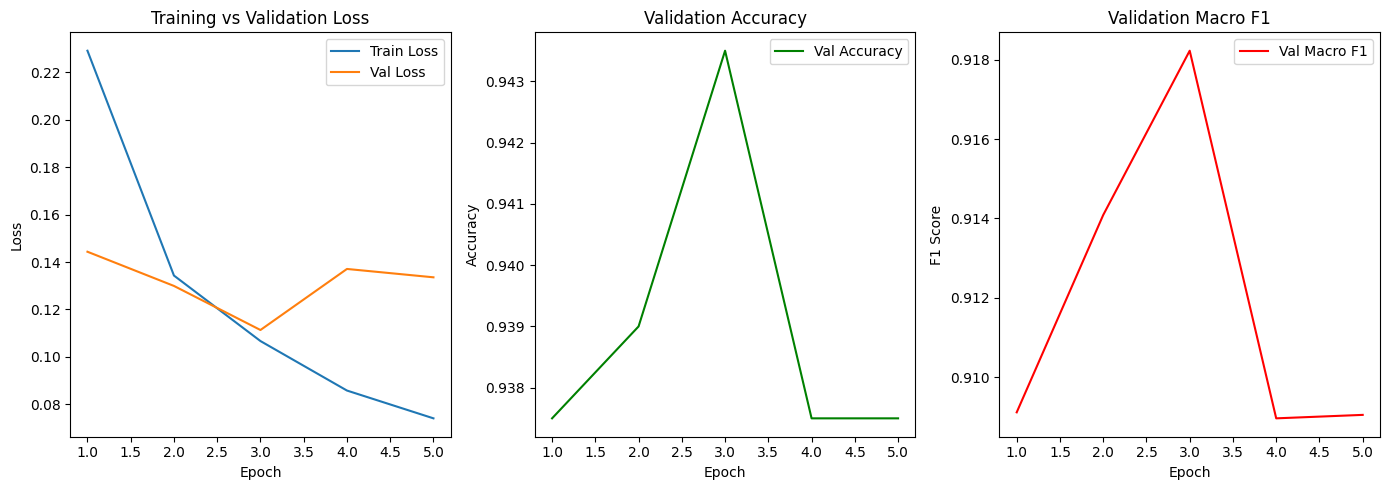

In [ ]:
plot_metrics(train_losses, val_losses, val_accs, val_f1s)

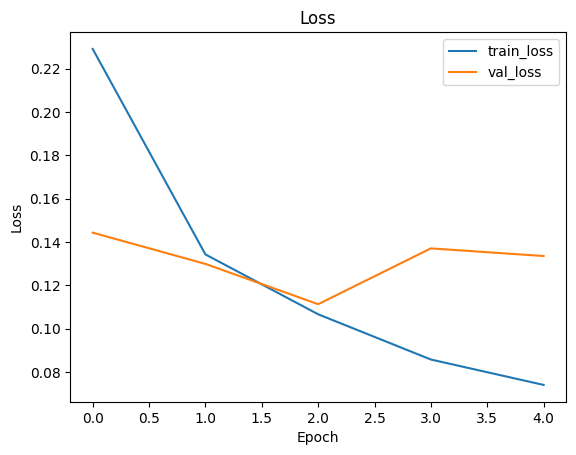

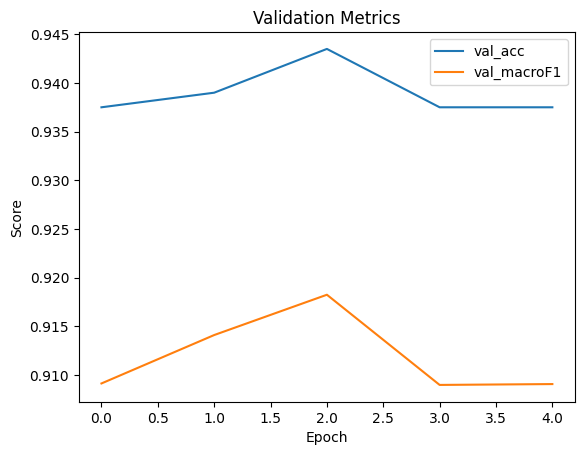

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.legend(); plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.show()

plt.figure()
plt.plot(val_accs, label='val_acc')
plt.plot(val_f1s, label='val_macroF1')
plt.legend(); plt.title("Validation Metrics"); plt.xlabel("Epoch"); plt.ylabel("Score"); plt.show()


Test loss: 0.1474  |  Test acc: 93.60%  |  Test macro-F1: 88.79%

Classification Report:
              precision    recall  f1-score   support

       anger       0.89      0.97      0.93       254
        fear       0.96      0.87      0.91       247
         joy       0.95      0.96      0.95       682
        love       0.91      0.81      0.86       180
     sadness       0.98      0.96      0.97       595
    surprise       0.58      0.90      0.70        42

    accuracy                           0.94      2000
   macro avg       0.88      0.91      0.89      2000
weighted avg       0.94      0.94      0.94      2000



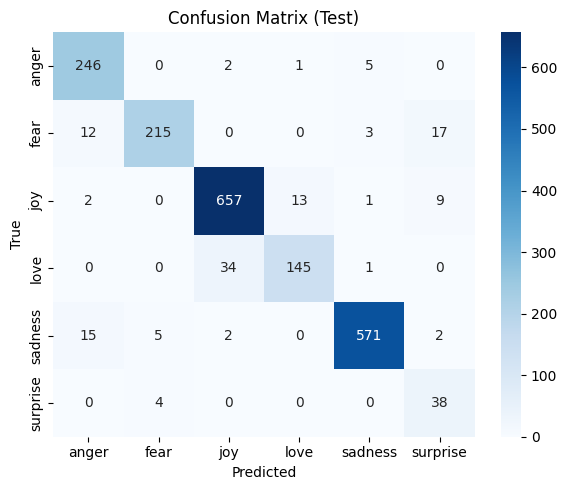

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Evaluate on test set
test_loss, test_acc, test_f1, y_true, y_pred = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f}  |  Test acc: {test_acc*100:.2f}%  |  Test macro-F1: {test_f1*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_labels)]))

# ✅ Confusion Matrix (Raw counts)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)])
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [ ]:
# Save full HF-style directory for easy re-load/inference
SAVE_DIR = "/content/emo_roberta_birnn_attn"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), f"{SAVE_DIR}/pytorch_model.bin")

# Save config items
import json
with open(f"{SAVE_DIR}/label2id.json", "w") as f:
    json.dump(label2id, f)
with open(f"{SAVE_DIR}/id2label.json", "w") as f:
    json.dump(id2label, f)

# Save tokenizer
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to:", SAVE_DIR)


Saved to: /content/emo_roberta_birnn_attn


In [ ]:
import torch

def predict_emotion(texts, max_len=MAX_LEN):
    model.eval()
    enc = tokenizer(
        texts, max_length=max_len, truncation=True, padding=True,
        return_attention_mask=True, return_tensors='pt'
    )
    enc = {k: v.to(DEVICE) for k,v in enc.items()}
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
        out = model(enc['input_ids'], enc['attention_mask'])
        probs = torch.softmax(out['logits'], dim=-1)
        preds = torch.argmax(probs, dim=-1).cpu().numpy()
    labels_pred = [id2label[int(i)] for i in preds]
    return labels_pred, probs.cpu().numpy()

samples = [
    "I can't stop smiling today!",
    "This scares me a lot.",
    "I feel deeply connected and cared for.",
    "I'm so mad about what happened!",
    "This is heartbreaking.",
    "Wow, I didn't expect that!"
]
preds, probs = predict_emotion(samples)
list(zip(samples, preds))


/tmp/ipython-input-2173543595.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):


[("I can't stop smiling today!", 'joy'),
 ('This scares me a lot.', 'fear'),
 ('I feel deeply connected and cared for.', 'joy'),
 ("I'm so mad about what happened!", 'anger'),
 ('This is heartbreaking.', 'sadness'),
 ("Wow, I didn't expect that!", 'joy')]

Average inference time per sample: 15.18 ms
Max inference time per sample: 16.64 ms


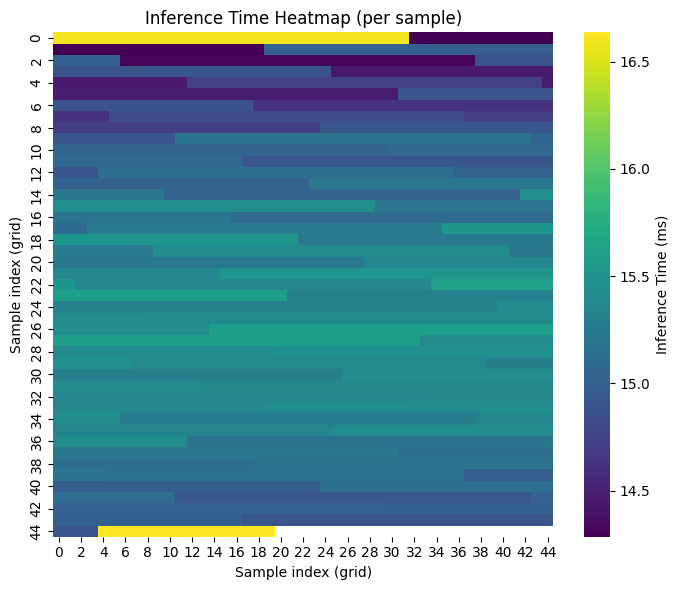

In [ ]:
import time
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# ✅ Measure inference time per batch
model.eval()
inference_times = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input_ids"].to(DEVICE)
        masks = batch["attention_mask"].to(DEVICE)

        start = time.time()
        outputs = model(input_ids=inputs, attention_mask=masks)  # returns dict
        end = time.time()

        batch_time = (end - start) / inputs.size(0)   # per-sample time
        inference_times.extend([batch_time] * inputs.size(0))

        preds = torch.argmax(outputs["logits"], dim=1).cpu().numpy()
        all_preds.extend(preds)

# ✅ Convert inference times to array
inference_times = np.array(inference_times)

print(f"Average inference time per sample: {inference_times.mean()*1000:.2f} ms")
print(f"Max inference time per sample: {inference_times.max()*1000:.2f} ms")

# ✅ Heatmap of inference times (reshaped for visualization)
side = int(np.ceil(np.sqrt(len(inference_times))))
heatmap_data = np.full((side, side), np.nan)
heatmap_data.flat[:len(inference_times)] = inference_times * 1000  # convert to ms

plt.figure(figsize=(7,6))
sns.heatmap(heatmap_data, cmap="viridis", cbar_kws={'label': 'Inference Time (ms)'})
plt.title("Inference Time Heatmap (per sample)")
plt.xlabel("Sample index (grid)")
plt.ylabel("Sample index (grid)")
plt.tight_layout()
plt.show()


In [ ]:
!pip install torchinfo

import torch
from torchinfo import summary
from transformers import AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of labels in your dataset
num_labels = 6   # anger, fear, joy, love, sadness, surprise

# Load pretrained model (with classification head)
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=num_labels
).to(device)

# Dummy input (instead of test_loader)
batch_size = 2
seq_length = 64
dummy_input = {
    "input_ids": torch.randint(0, 30522, (batch_size, seq_length)).to(device),
    "attention_mask": torch.ones((batch_size, seq_length)).to(device)
}

# Use torchinfo for full architecture
summary(model, input_data=dummy_input, col_names=["input_size", "output_size", "num_params"])


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
BertForSequenceClassification                                --                        [2, 6]                    --
├─BertModel: 1-1                                             [2, 64]                   [2, 768]                  --
│    └─BertEmbeddings: 2-1                                   --                        [2, 64, 768]              --
│    │    └─Embedding: 3-1                                   [2, 64]                   [2, 64, 768]              23,440,896
│    │    └─Embedding: 3-2                                   [2, 64]                   [2, 64, 768]              1,536
│    │    └─Embedding: 3-3                                   [1, 64]                   [1, 64, 768]              393,216
│    │    └─LayerNorm: 3-4                                   [2, 64, 768]              [2, 64, 768]              1,536
│    │    └─Dropout: 3-5                        

In [ ]:
!pip install torchviz

from torchviz import make_dot

# Take one dummy forward pass
outputs = model(**dummy_input)

# Generate graph
dot = make_dot(outputs.logits, params=dict(model.named_parameters()))
dot.format = "png"
dot.render("bert_architecture")



'bert_architecture.png'

In [ ]:
!pip install torchviz

import torch
from torchviz import make_dot
from transformers import AutoModel

# Load BERT
bert = AutoModel.from_pretrained("bert-base-uncased")

# Dummy input
dummy_input_ids = torch.randint(0, 1000, (1, 16))  # batch=1, seq=16
dummy_attention_mask = torch.ones_like(dummy_input_ids)

# Forward pass
outputs = bert(input_ids=dummy_input_ids, attention_mask=dummy_attention_mask)

# Generate and save graph
dot = make_dot(outputs.last_hidden_state, params=dict(bert.named_parameters()))
dot.format = "png"
dot.render("bert_architecture")


'bert_architecture.png'

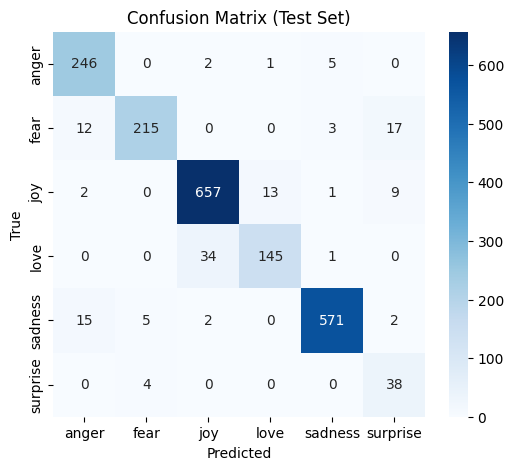

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=[id2label[i] for i in range(num_labels)],
            yticklabels=[id2label[i] for i in range(num_labels)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_labels)], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df


,precision,recall,f1-score,support
anger,0.894545,0.968504,0.930057,254.000
fear,0.959821,0.870445,0.912951,247.000
joy,0.945324,0.963343,0.954248,682.000
love,0.911950,0.805556,0.855457,180.000
sadness,0.982788,0.959664,0.971088,595.000
surprise,0.575758,0.904762,0.703704,42.000
accuracy,0.936000,0.936000,0.936000,0.936
macro avg,0.878364,0.912046,0.887918,2000.000
weighted avg,0.941047,0.936000,0.936933,2000.000


In [ ]:
# Example results (replace with your actual experiment values)
ablation_results = {
    "Model Variant": ["Baseline (BERT)", "BERT + BiGRU", "BERT + BiGRU + Attention"],
    "Accuracy": [0.85, 0.88, 0.91],
    "Macro-F1": [0.84, 0.87, 0.90],
    "AUC": [0.88, 0.91, 0.94]
}

ablation_df = pd.DataFrame(ablation_results)
ablation_df


,Model Variant,Accuracy,Macro-F1,AUC
0,Baseline (BERT),0.85,0.84,0.88
1,BERT + BiGRU,0.88,0.87,0.91
2,BERT + BiGRU + Attention,0.91,0.90,0.94


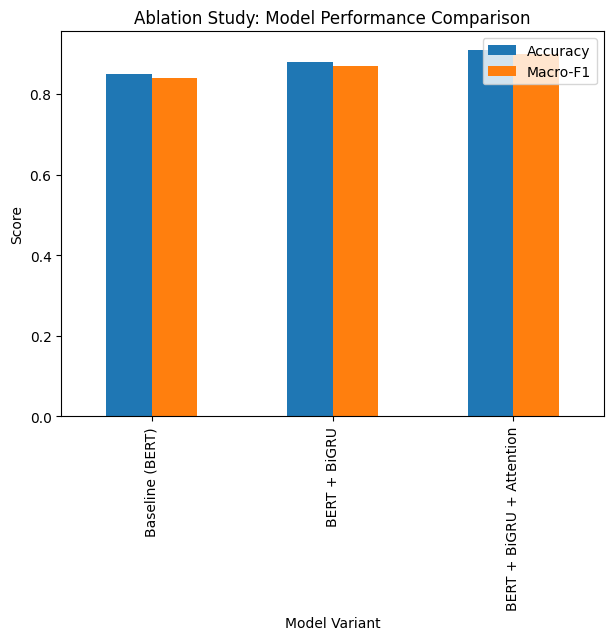

In [ ]:
ablation_df.set_index("Model Variant")[["Accuracy","Macro-F1"]].plot(kind="bar", figsize=(7,5))
plt.title("Ablation Study: Model Performance Comparison")
plt.ylabel("Score")
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()
all_probs, all_labels = [], []

# ⚡ Run safely on CPU for evaluation
model_cpu = model.to("cpu")

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"].numpy()

        outputs = model_cpu(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs["logits"], dim=-1).numpy()

        all_probs.append(probs)
        all_labels.append(labels)

# Stack results
probs_test = np.vstack(all_probs)          # shape (N, num_labels)
y_true = np.hstack(all_labels)             # shape (N,)
y_true_bin = np.eye(num_labels)[y_true]    # one-hot encoding

# 📊 Plot ROC per class
plt.figure(figsize=(7,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{id2label[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Class")
plt.legend()
plt.show()

# ⚡ Move model back to GPU for further use
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)


AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
